In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def format_scientific(val: float, digits: int = 2) -> str:
    mantissa, exponent = f"{val:.{digits}e}".split('e')
    return f"${mantissa}e{{{int(exponent)}}}$"

In [3]:
def sort_by_vertices(df, french_map):
    """Sort dataframe by number of vertices extracted from 'Sommets' in dataFileName"""
    df = df.copy()
    df['temp_sort'] = df['dataFileName'].str.replace('Sommets', '').map(french_map)
    return df.sort_values('temp_sort').drop(columns=['temp_sort']).reset_index(drop=True)

def export_to_latex(df, drop_cols=['dataFileName']):
    """Prepare dataframe for LaTeX export with formatted values"""
    export_df = df.drop(columns=drop_cols).copy()
    # export_df['solutionValue'] = export_df['solutionValue'].astype(int)
    export_df['solutionValue'] = pd.to_numeric(export_df['solutionValue'], errors='raise').astype(int)
    # export_df['cpuTime'] = export_df['cpuTime'].apply(format_scientific)
    export_df['cpuTime'] = pd.to_numeric(export_df['cpuTime'], errors='raise').apply(format_scientific)
    return export_df

def format_latex_scientific(val):
    """Format a numeric value as LaTeX-friendly scientific notation without dollar signs."""
    mantissa, exponent = f"{float(val):.2e}".split('e')
    return f"{mantissa}e{{{int(exponent)}}}"

def _to_solution_text(value):
    if pd.isna(value) or (isinstance(value, str) and value.lower() == 'missing'):
        return '--'
    return str(int(float(value)))

def _to_cpu_text(value):
    if pd.isna(value) or (isinstance(value, str) and value.lower() == 'missing'):
        return '--'
    if isinstance(value, str):
        try:
            return format_latex_scientific(value)
        except ValueError:
            return value
    return format_latex_scientific(value)

def _prepare_ags_with_epsilon(df):
    export_df = df.copy()
    if 'Epsilon' not in export_df.columns:
        if 'logFile' not in export_df.columns:
            raise ValueError("AGS export requires either an 'Epsilon' column or a 'logFile' column.")
        export_df['Epsilon'] = (
            export_df['logFile']
            .str.extract(r'_EPS([0-9]+(?:\.[0-9]+)?)', expand=False)
            .astype(float)
        )
    return export_df

def export_ags_latex_table(df, output_path, epsilon=0):
    """Write AGS results as a LaTeX-ready text table grouped by p and sorted by instance size."""
    export_df = _prepare_ags_with_epsilon(df)
    export_df = export_df[export_df['Epsilon'] == epsilon].copy()
    export_df['temp_sort'] = (
        export_df['dataFileName']
        .astype(str)
        .str.strip()
        .str.replace('Sommets', '', regex=False)
        .map(french_num_map)
    )
    export_df = export_df.sort_values(['Number of classes', 'temp_sort', 'dataFileName']).drop(columns=['temp_sort'])

    lines = ['\\hline']
    for _, row in export_df.iterrows():
        lines.append(
            f"{row['dataFileName']} & {int(row['Number of classes'])} & {_to_solution_text(row['solutionValue'])} & {_to_cpu_text(row['cpuTime'])} \\\\"
        )
    lines.append('\\hline')

    with open(output_path, 'w', encoding='utf-8') as latex_file:
        latex_file.write('\n'.join(lines))

    return export_df

def export_ags_latex_table_p2_all_eps(df, output_path):
    """Write a copy-paste-friendly AGS LaTeX table for p = 2 with all epsilon values."""
    export_df = _prepare_ags_with_epsilon(df)
    export_df = export_df[export_df['Number of classes'] == 2].copy()
    export_df['temp_sort'] = (
        export_df['dataFileName']
        .astype(str)
        .str.strip()
        .str.replace('Sommets', '', regex=False)
        .map(french_num_map)
    )
    export_df = export_df.sort_values(['Epsilon', 'temp_sort', 'dataFileName']).drop(columns=['temp_sort'])

    def format_eps(val):
        if float(val).is_integer():
            return str(int(val))
        return str(val).rstrip('0').rstrip('.')

    lines = ['\\hline']
    current_eps = None
    for _, row in export_df.iterrows():
        epsilon = row['Epsilon']
        if current_eps is None:
            current_eps = epsilon
        elif epsilon != current_eps:
            lines.append('\\hline')
            current_eps = epsilon
        lines.append(
            f"{row['dataFileName']} & {int(row['Number of classes'])} & {format_eps(epsilon)} & {_to_solution_text(row['solutionValue'])} & {_to_cpu_text(row['cpuTime'])} \\\\"
        )

    lines.append('\\hline')

    with open(output_path, 'w', encoding='utf-8') as latex_file:
        latex_file.write('\n'.join(lines))

    return export_df

def export_ags_latex_table_p_wide(df, output_path, p):
    export_df = _prepare_ags_with_epsilon(df)
    export_df = export_df[export_df['Number of classes'] == p].copy()
    export_df['temp_sort'] = (
        export_df['dataFileName']
        .astype(str)
        .str.strip()
        .str.replace('Sommets', '', regex=False)
        .map(french_num_map)
    )
    export_df = export_df.sort_values(['temp_sort', 'dataFileName'])

    eps_values = [0.0, 0.5, 1.0]
    lines = [
        r'\multirow{2}{*}{\textbf{Instance}} & \multirow{2}{*}{\textbf{p}} & \multicolumn{3}{c|}{\textbf{MinCut}} & \multicolumn{3}{c|}{\textbf{CPU (s)}} \\',
        r'\cline{3-8}',
        r'& & $\epsilon=0.0$ & $\epsilon=0.5$ & $\epsilon=1.0$ & $\epsilon=0.0$ & $\epsilon=0.5$ & $\epsilon=1.0$ \\',
        r'\hline'
    ]

    for instance, group in export_df.groupby('dataFileName', sort=False):
        group_by_eps = group.set_index('Epsilon')
        mincuts = []
        cputimes = []
        for eps in eps_values:
            if eps in group_by_eps.index:
                row = group_by_eps.loc[eps]
                if isinstance(row, pd.DataFrame):
                    row = row.iloc[0]
                mincuts.append(_to_solution_text(row['solutionValue']))
                cputimes.append(_to_cpu_text(row['cpuTime']))
            else:
                mincuts.append('--')
                cputimes.append('--')
        lines.append(
            f"{instance} & {p} & {mincuts[0]} & {mincuts[1]} & {mincuts[2]} & ${cputimes[0]}$ & ${cputimes[1]}$ & ${cputimes[2]}$ \\\\"
        )

    lines.append(r'\hline')

    with open(output_path, 'w', encoding='utf-8') as latex_file:
        latex_file.write('\n'.join(lines))

    return export_df

# Define mapping from French number names to integers
french_num_map = {
    'quatre': 4, 'cinq': 5, 'dix': 10, 'quinze': 15, 'dixSept': 17,
    'vingt': 20, 'vingtEtun': 21, 'vingtDeux': 22, 'vingtTrois': 23,
    'vingtQuatre': 24, 'vingtCinq': 25, 'trente': 30, 'cinquante': 50,
    'cent': 100, 'cinqCent': 500, 'mille': 1000, 'dixMilleSommets': 10000
}

In [4]:
cremi_enum_data = pd.read_csv('enum/result_summary_A3_p2_3_4_5_6_e0.0_0.5_1.0.csv', sep=';')
cremi_enum_data = cremi_enum_data.drop(columns=['logFile', 'Algorithm', 'isFeasible'])
cremi_enum_data = cremi_enum_data[cremi_enum_data['Epsilon'] == 0].copy()
cremi_enum_data = cremi_enum_data[cremi_enum_data['Number of classes'] == 2].copy()
cremi_enum_data = cremi_enum_data.drop(columns=['Number of classes', 'Epsilon'])
cremi_enum_data = sort_by_vertices(cremi_enum_data, french_num_map)
cremi_enum_n = (
    cremi_enum_data['dataFileName']
    .astype(str)
    .str.strip()
    .str.replace('Sommets', '', regex=False)
    .map(french_num_map)
)

In [5]:
cremi_recGradient_data = pd.read_csv('gradient_versionRecursive/Grad_p2.csv', sep=';')
cremi_recGradient_data = cremi_recGradient_data.drop(columns=['Algorithm', 'Number of classes', 
                                                              'Number of multi-start runs for Gradient', 'multi_best',
                                                              'multi_worst', 'multi_mean', 'multi_median', 'multi_std_dev',
                                                              'multi_nb_best_found', 'multi_nb_runs', 'solutionValue',
                                                              'isFeasible', 'Time limit'])
cremi_recGradient_data = cremi_recGradient_data[cremi_recGradient_data['Epsilon'] == 0].copy()
cremi_recGradient_data = cremi_recGradient_data.drop(columns=['Epsilon'], errors='ignore')
cremi_recGradient_data['logFile'] = cremi_recGradient_data['logFile'].str.split('_').str[0]

# Sort by number of vertices using the cleaned logFile values
cremi_recGradient_data['temp_sort'] = (
    cremi_recGradient_data['logFile']
    .str.replace('Sommets', '', regex=False)
    .map(french_num_map)
)
cremi_recGradient_data = cremi_recGradient_data.sort_values('temp_sort').drop(columns=['temp_sort']).reset_index(drop=True)
cremi_recGradient_n = (
    cremi_recGradient_data['logFile']
    .str.replace('Sommets', '', regex=False)
    .map(french_num_map)
)

In [6]:
cremi_enumKL_data = pd.read_csv('KL/result_A3_p2_e0_enum_cremi.csv', sep=';')
cremi_enumKL_data = cremi_enumKL_data.drop(columns=['logFile', 'Algorithm', 'Number of classes', 'isFeasible'])
cremi_enumKL_data = sort_by_vertices(cremi_enumKL_data, french_num_map)
cremi_enumKL_n = (
    cremi_enumKL_data['dataFileName']
    .astype(str)
    .str.strip()
    .str.replace('Sommets', '', regex=False)
    .map(french_num_map)
)

In [7]:
# Load and process CREMI data
mypc_heapKL_data = pd.read_csv('KL/result_A3_p2_e0_heap_mypc.csv', sep=';')
mypc_heapKL_data = mypc_heapKL_data.drop(columns=['logFile', 'Algorithm', 'Number of classes', 'isFeasible'])
mypc_heapKL_data = sort_by_vertices(mypc_heapKL_data, french_num_map)
mypc_heapKL_n = mypc_heapKL_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [8]:
# Load and process CREMI data
cremi_heapKL_data = pd.read_csv('KL/result_A3_p2_e0_heap_cremi.csv', sep=';')
cremi_heapKL_data = cremi_heapKL_data.drop(columns=['logFile', 'Algorithm', 'Number of classes', 'isFeasible'])
cremi_heapKL_data = sort_by_vertices(cremi_heapKL_data, french_num_map)
cremi_heapKL_n = cremi_heapKL_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)


In [9]:
# Load and process NetworkX data
cremi_NetworkX_data = pd.read_csv('KL/result_A3_p2_e0_NetworkX_cremi.csv', sep=';')
cremi_NetworkX_data = cremi_NetworkX_data.drop(
    columns=['logFile', 'Algorithm', 'Number of classes', 'isFeasible'],
    errors='ignore'
 )
cremi_NetworkX_data = sort_by_vertices(cremi_NetworkX_data, french_num_map)
cremi_NetworkX_n = cremi_NetworkX_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)


In [10]:
mypc_AGS_data = pd.read_csv('AGs/result_A6_p2_3_4_5_6_e0_0.5_1_mypc.csv', sep=';')
mypc_AGS_data['Epsilon'] = (
    mypc_AGS_data['logFile']
    .str.extract(r'_EPS([0-9]+(?:\.[0-9]+)?)', expand=False)
    .astype(float)
 )
mypc_AGS_data = mypc_AGS_data.drop(columns=['logFile', 'Algorithm', 'isFeasible'])
mypc_AGS_data = mypc_AGS_data[mypc_AGS_data['Epsilon'] == 0].copy()
mypc_AGS_data = mypc_AGS_data[mypc_AGS_data['Number of classes'] == 2].copy()
mypc_AGS_data = mypc_AGS_data.drop(columns=['Number of classes', 'Epsilon'])
mypc_AGS_data = sort_by_vertices(mypc_AGS_data, french_num_map)
mypc_AGS_n = mypc_AGS_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [11]:
cremi_RecSim_data = pd.read_csv('Recuit Simule/result_summary_recuit_p2.csv', sep=';')
cremi_RecSim_data = cremi_RecSim_data.drop(
    columns=['logFile', 'nb_runs', 'elapsed_time',
       'best', 'worst', 'mean', 'median', 'std_dev', 'nb_best_found', 
       'cpu_mean', 'T0_best', 'Tf_best', 'T0_mean', 'Tf_mean',
       'solution_file',],
    errors='ignore'
 )
cremi_RecSim_data = cremi_RecSim_data[cremi_RecSim_data['epsilon'] == 0.0].copy()
cremi_RecSim_data['dataFileName'] = (
    cremi_RecSim_data['data_file']
    .astype(str)
    .str.replace('data/', '', regex=False)
    .str.replace('.txt', '', regex=False)
 )
cremi_RecSim_data = cremi_RecSim_data.drop(columns=['data_file'], errors='ignore')
cremi_RecSim_data = sort_by_vertices(cremi_RecSim_data, french_num_map)
cremi_RecSim_n = cremi_RecSim_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [12]:
cremi_gradHeu_data = pd.read_csv('Gradient+heuristique/GH_p2_k5.csv', sep=';')
cremi_gradHeu_data = cremi_gradHeu_data.drop(columns=['Algorithm', 'Time limit',
       'Number of multi-start runs for Gradient', 'multi_best', 'multi_worst',
       'multi_mean', 'multi_median', 'multi_std_dev', 'multi_nb_best_found',
       'multi_nb_runs', 'solutionValue', 'isFeasible'])
cremi_gradHeu_data = cremi_gradHeu_data[cremi_gradHeu_data['Epsilon'] == 0.0].copy()
cremi_gradHeu_data['dataFileName'] = (
    cremi_gradHeu_data['logFile']
    .astype(str)
    .str.split('_').str[0]
 )
cremi_gradHeu_data = cremi_gradHeu_data.drop(columns=['logFile'])
cremi_gradHeu_data = sort_by_vertices(cremi_gradHeu_data, french_num_map)
cremi_gradHeu_n = cremi_gradHeu_data['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
markers = ['s', 'o', 'x', '^', 'D', 'v', '*']

def plot_comparison(plt_data_table, ax=None, title='Zoom sur les petites instances', n_max=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    for plt_i in range(len(plt_data_table)):
        y_vals = plt_data_table[plt_i][0]
        x_vals = plt_data_table[plt_i][1]
        label = plt_data_table[plt_i][2]

        if n_max is not None:
            mask = x_vals <= n_max
            x_plot = x_vals[mask]
            y_plot = y_vals[mask]
        else:
            x_plot = x_vals
            y_plot = y_vals

        ax.plot(
            x_plot,
            y_plot,
            marker=markers[plt_i % len(markers)],
            # label=label,
            linewidth=2
        )

    if n_max is not None:
        ax.set_xlim(0, n_max)

    ax.set_xlabel('Nombre de sommets n', fontsize=12)
    ax.set_ylabel('Temps CPU (s)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)

    return plt

def plot_comparison_with_zoom(plt_data_table, n_max=None, output_path=None, yscale='linear'):
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_comparison(
        plt_data_table,
        ax=ax,
        title='Temps de calcul en fonction de n',
        n_max=n_max
    )

    if yscale == 'log':
        ax.set_yscale('log')
        ax.set_ylim(bottom=0.01)

    ax.legend(fontsize=11, loc='lower right')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300)
    plt.show()


In [18]:
plt_data_table = [
  [cremi_enum_data['cpuTime'], cremi_enum_n, 'Enum non optimisé'],    
  [cremi_recGradient_data['cpuTime'], cremi_recGradient_n, 'Gradient recursive'],
  [cremi_enumKL_data['cpuTime'], cremi_enumKL_n, 'KL enum'], 
  # [mypc_heapKL_data['cpuTime'], mypc_heapKL_n, 'KL heap MyPC'],
  [cremi_heapKL_data['cpuTime'], cremi_heapKL_n, 'KL heap'],    
  [cremi_NetworkX_data['cpuTime'], cremi_NetworkX_n, 'NetworkX'], 
  [cremi_gradHeu_data['cpuTime'], cremi_gradHeu_n, 'Gradient heuristique'],
  [cremi_RecSim_data['cpu_total'], cremi_RecSim_n, 'RecSim'],
  [mypc_AGS_data['cpuTime'], mypc_AGS_n, 'AGS']  
                  ]

/tmp/ipykernel_93400/1793996495.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='lower right')


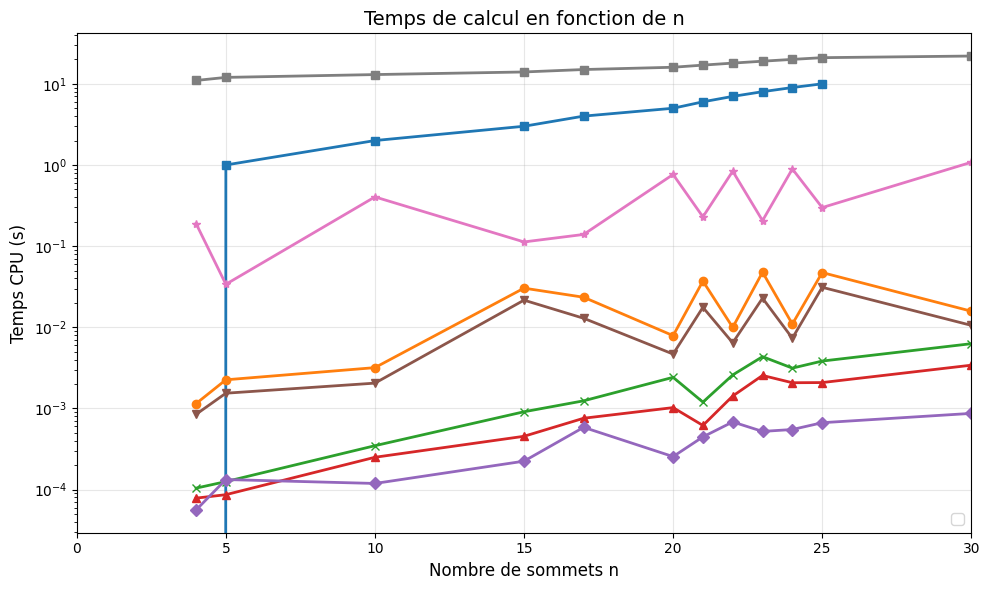

In [21]:
plot_comparison_with_zoom(
    plt_data_table,
    n_max=30,
    output_path='../assets/plot_Enum_Grad_KL_NetworkX_GradHeu_RecSim_AGS_n30.png',
    yscale='log'
 )

In [ ]:
# plot_comparison(plt_data_table)

plt = plot_comparison(plt_data_table)
plt.yscale('log')
plt.legend(fontsize=11, loc='upper right')

## AGS


In [ ]:
mypc_AGS_data = pd.read_csv('AGs/result_A6_p2_3_4_5_6_e0_0.5_1_mypc.csv', sep=';')
mypc_AGS_data['Epsilon'] = (
    mypc_AGS_data['logFile']
    .str.extract(r'_EPS([0-9]+(?:\.[0-9]+)?)', expand=False)
    .astype(float)
 )
mypc_AGS_data = mypc_AGS_data.drop(columns=['logFile', 'Algorithm', 'isFeasible'])

### AGS plot of eps

In [ ]:
mypc_AGS_data_eps0 = mypc_AGS_data.copy()

mypc_AGS_data_eps0 = mypc_AGS_data_eps0[mypc_AGS_data_eps0['Number of classes'] == 2].copy()
mypc_AGS_data_eps0 = mypc_AGS_data_eps0[mypc_AGS_data_eps0['Epsilon'] == 0].copy()

mypc_AGS_data_eps0 = sort_by_vertices(mypc_AGS_data_eps0, french_num_map)
mypc_AGS_n_eps0 = mypc_AGS_data_eps0['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
mypc_AGS_data_eps0_5 = mypc_AGS_data.copy()

mypc_AGS_data_eps0_5 = mypc_AGS_data_eps0_5[mypc_AGS_data_eps0_5['Number of classes'] == 2].copy()
mypc_AGS_data_eps0_5 = mypc_AGS_data_eps0_5[mypc_AGS_data_eps0_5['Epsilon'] == 0.5].copy()

mypc_AGS_data_eps0_5 = sort_by_vertices(mypc_AGS_data_eps0_5, french_num_map)
mypc_AGS_n_eps0_5 = mypc_AGS_data_eps0_5['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
mypc_AGS_data_eps1 = mypc_AGS_data.copy()

mypc_AGS_data_eps1 = mypc_AGS_data_eps1[mypc_AGS_data_eps1['Number of classes'] == 2].copy()
mypc_AGS_data_eps1 = mypc_AGS_data_eps1[mypc_AGS_data_eps1['Epsilon'] == 1].copy()

mypc_AGS_data_eps1 = sort_by_vertices(mypc_AGS_data_eps1, french_num_map)
mypc_AGS_n_eps1 = mypc_AGS_data_eps1['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
plt_data_table = [
    [mypc_AGS_data_eps0['cpuTime'], mypc_AGS_n_eps0, r'$\epsilon = 0$'],
    [mypc_AGS_data_eps0_5['cpuTime'], mypc_AGS_n_eps0_5, r'$\epsilon = 0.5$'],
    [mypc_AGS_data_eps1['cpuTime'], mypc_AGS_n_eps1, r'$\epsilon = 1$'],
]

In [ ]:
plot_comparison_with_zoom(
    plt_data_table,
    # n_max=100,
    output_path='../assets/plot_AGS_eps_comparison.png',
    yscale='log'
 )

### AGS plot of eps with n=10

In [ ]:
mypc_AGS_data_eps0_n10 = mypc_AGS_data.copy()

mypc_AGS_data_eps0_n10 = mypc_AGS_data_eps0_n10[mypc_AGS_data_eps0_n10['dataFileName'] == 'dixSommets'].copy()
mypc_AGS_data_eps0_n10 = mypc_AGS_data_eps0_n10[mypc_AGS_data_eps0_n10['Epsilon'] == 0].copy()
mypc_AGS_data_eps0_n10 = mypc_AGS_data_eps0_n10.sort_values('Number of classes', ascending=True).reset_index(drop=True)

In [ ]:
mypc_AGS_data_eps0_5_n10 = mypc_AGS_data.copy()

mypc_AGS_data_eps0_5_n10 = mypc_AGS_data_eps0_5_n10[mypc_AGS_data_eps0_5_n10['dataFileName'] == 'dixSommets'].copy()
mypc_AGS_data_eps0_5_n10 = mypc_AGS_data_eps0_5_n10[mypc_AGS_data_eps0_5_n10['Epsilon'] == 0.5].copy()
mypc_AGS_data_eps0_5_n10 = mypc_AGS_data_eps0_5_n10.sort_values('Number of classes', ascending=True).reset_index(drop=True)

In [ ]:
mypc_AGS_data_eps1_n10 = mypc_AGS_data.copy()

mypc_AGS_data_eps1_n10 = mypc_AGS_data_eps1_n10[mypc_AGS_data_eps1_n10['dataFileName'] == 'dixSommets'].copy()
mypc_AGS_data_eps1_n10 = mypc_AGS_data_eps1_n10[mypc_AGS_data_eps1_n10['Epsilon'] == 1].copy()
mypc_AGS_data_eps1_n10 = mypc_AGS_data_eps1_n10.sort_values('Number of classes', ascending=True).reset_index(drop=True)

In [ ]:
mypc_AGS_n10 = pd.DataFrame({2, 3, 4, 5, 6})

plt_data_table = [
    [mypc_AGS_data_eps0_n10['cpuTime'], mypc_AGS_n10, r'$\epsilon = 0$'],
    [mypc_AGS_data_eps0_5_n10['cpuTime'], mypc_AGS_n10, r'$\epsilon = 0.5$'],
    [mypc_AGS_data_eps1_n10['cpuTime'], mypc_AGS_n10, r'$\epsilon = 1$'],
]

In [ ]:
plot_comparison_with_zoom(
    plt_data_table,
    # n_max=100,
    output_path='../assets/plot_AGS_eps_n10_comparison.png',
    yscale='log'
 )

### AGS plot of k

In [ ]:
mypc_AGS_data = pd.read_csv('AGs/result_A6_p2_3_4_5_6_e0_0.5_1_mypc.csv', sep=';')
mypc_AGS_data['Epsilon'] = (
    mypc_AGS_data['logFile']
    .str.extract(r'_EPS([0-9]+(?:\.[0-9]+)?)', expand=False)
    .astype(float)
 )
mypc_AGS_data = mypc_AGS_data.drop(columns=['logFile', 'Algorithm', 'isFeasible'])

In [ ]:
mypc_AGS_data_k2 = mypc_AGS_data.copy()

mypc_AGS_data_k2 = mypc_AGS_data_k2[mypc_AGS_data_k2['Epsilon'] == 0].copy()
mypc_AGS_data_k2 = mypc_AGS_data_k2[mypc_AGS_data_k2['Number of classes'] == 2].copy()

mypc_AGS_data_k2 = sort_by_vertices(mypc_AGS_data_k2, french_num_map)
mypc_AGS_n_k2 = mypc_AGS_data_k2['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
mypc_AGS_data_k3 = mypc_AGS_data.copy()

mypc_AGS_data_k3 = mypc_AGS_data_k3[mypc_AGS_data_k3['Epsilon'] == 0].copy()
mypc_AGS_data_k3 = mypc_AGS_data_k3[mypc_AGS_data_k3['Number of classes'] == 3].copy()

mypc_AGS_data_k3 = sort_by_vertices(mypc_AGS_data_k3, french_num_map)
mypc_AGS_n_k3 = mypc_AGS_data_k3['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
mypc_AGS_data_k4 = mypc_AGS_data.copy()

mypc_AGS_data_k4 = mypc_AGS_data_k4[mypc_AGS_data_k4['Epsilon'] == 0].copy()
mypc_AGS_data_k4 = mypc_AGS_data_k4[mypc_AGS_data_k4['Number of classes'] == 4].copy()

mypc_AGS_data_k4 = sort_by_vertices(mypc_AGS_data_k4, french_num_map)
mypc_AGS_n_k4 = mypc_AGS_data_k4['dataFileName'].str.replace('Sommets', '').map(french_num_map)

In [ ]:
mypc_AGS_data_k5 = mypc_AGS_data.copy()

mypc_AGS_data_k5 = mypc_AGS_data_k5[mypc_AGS_data_k5['Epsilon'] == 0].copy()
mypc_AGS_data_k5 = mypc_AGS_data_k5[mypc_AGS_data_k5['Number of classes'] == 5].copy()

mypc_AGS_data_k5 = sort_by_vertices(mypc_AGS_data_k5, french_num_map)
mypc_AGS_n_k5 = mypc_AGS_data_k5['dataFileName'].str.replace('Sommets', '').map(french_num_map)


In [ ]:
mypc_AGS_data_k6 = mypc_AGS_data.copy()

mypc_AGS_data_k6 = mypc_AGS_data_k6[mypc_AGS_data_k6['Epsilon'] == 0].copy()
mypc_AGS_data_k6 = mypc_AGS_data_k6[mypc_AGS_data_k6['Number of classes'] == 6].copy()

mypc_AGS_data_k6 = sort_by_vertices(mypc_AGS_data_k6, french_num_map)
mypc_AGS_n_k6 = mypc_AGS_data_k6['dataFileName'].str.replace('Sommets', '').map(french_num_map)


In [ ]:
plt_data_table = [
    [mypc_AGS_data_k2['cpuTime'], mypc_AGS_n_k2, 'p = 2'],
    [mypc_AGS_data_k3['cpuTime'], mypc_AGS_n_k3, 'p = 3'],
    [mypc_AGS_data_k4['cpuTime'], mypc_AGS_n_k4, 'p = 4'],
    [mypc_AGS_data_k5['cpuTime'], mypc_AGS_n_k5, 'p = 5'],
    [mypc_AGS_data_k6['cpuTime'], mypc_AGS_n_k6, 'p = 6'],
]

In [ ]:
plot_comparison_with_zoom(
    plt_data_table,
    # n_max=100,
    output_path='../assets/plot_AGS_p_comparison.png',
    yscale='log'
 )

### AGs latex exportation

In [ ]:
# mypc_AGS_data_latex = mypc_AGS_data.copy()
# mypc_AGS_data_latex = export_ags_latex_table_p_wide(mypc_AGS_data_latex, 'AGs/latex_AGS_p2.txt', 2)

# mypc_AGS_data_latex = mypc_AGS_data.copy()
# mypc_AGS_data_latex = export_ags_latex_table_p_wide(mypc_AGS_data_latex, 'AGs/latex_AGS_p3.txt', 3)

# mypc_AGS_data_latex = mypc_AGS_data.copy()
# mypc_AGS_data_latex = export_ags_latex_table_p_wide(mypc_AGS_data_latex, 'AGs/latex_AGS_p4.txt', 4)

# mypc_AGS_data_latex = mypc_AGS_data.copy()
# mypc_AGS_data_latex = export_ags_latex_table_p_wide(mypc_AGS_data_latex, 'AGs/latex_AGS_p5.txt', 5)

# mypc_AGS_data_latex = mypc_AGS_data.copy()
# mypc_AGS_data_latex = export_ags_latex_table_p_wide(mypc_AGS_data_latex, 'AGs/latex_AGS_p6.txt', 6)

### KL latex exportation

In [ ]:
# # Export to LaTeX format
# cremi_enumKL_data_export = export_to_latex(cremi_enumKL_data)
# # cremi_enumKL_data_export.to_csv('KL/latex_enumKL.txt', index=False, sep='&')

# # mypc_heapKL_data_export = export_to_latex(mypc_heapKL_data)
# # mypc_heapKL_data_export.to_csv('KL/latex_heapKL_myPC.txt', index=False, sep='&')

# cremi_heapKL_data_export = export_to_latex(cremi_heapKL_data)
# # cremi_heapKL_data_export.to_csv('KL/latex_heapKL.txt', index=False, sep='&')

# cremi_NetworkX_export = export_to_latex(cremi_NetworkX_data)
# # cremi_NetworkX_export.to_csv('KL/latex_NetworkX.txt', index=False, sep='&')

In [ ]:
# # Generate combined LaTeX comparison
# combined_latex = (
#     cremi_enumKL_data[['dataFileName', 'solutionValue', 'cpuTime']]
#     .merge(
#         mypc_heapKL_data[['dataFileName', 'solutionValue', 'cpuTime']],
#         on='dataFileName',
#         suffixes=('_enumKL', '_heapKL_mypc')
#     )
#     .merge(
#         cremi_NetworkX_data[['dataFileName', 'solutionValue', 'cpuTime']],
#         on='dataFileName'
#     )
#     .rename(columns={
#         'solutionValue': 'solutionValue_networkx',
#         'cpuTime': 'cpuTime_networkx'
#     })
# )

# combined_latex['latex_line'] = combined_latex.apply(
#     lambda row: (
#         f" {row['dataFileName']} & {int(row['solutionValue_enumKL'])}"
#         f" & {format_scientific(row['cpuTime_enumKL'])}"
#         f" & {int(row['solutionValue_heapKL_mypc'])}"
#         f" & {format_scientific(row['cpuTime_heapKL_mypc'])}"
#         f" & {int(row['solutionValue_networkx'])}"
#         f" & {format_scientific(row['cpuTime_networkx'])} " + r"\\"
#     ),
#     axis=1
# )

# with open('latex_enumKL_heapKL_vs_networkx.txt', 'w', encoding='utf-8') as latex_file:
#     latex_file.write('\n'.join(combined_latex['latex_line']))

_____________________________